# Part 2 - Bias Audit: Who Does the Model Hurt?

This notebook audits disparity between two cohorts on the held-out 20,000-row evaluation subset:
- High-black cohort: `black >= 0.5`
- Reference cohort: `black < 0.1 and white >= 0.5`

Outputs required by the assignment:
- Cohort sizes
- Per-cohort metrics: TPR, FPR, FNR, Precision
- Disparate impact ratio: `FPR(high-black) / FPR(reference)`
- aif360 metrics: Statistical parity difference, Equal opportunity difference
- Grouped bar chart (TPR, FPR, FNR)
- Two confusion matrices (one per cohort)

In [ ]:
 !pip install -q transformers torch scikit-learn aif360 pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 10.3 MB/s eta 0:00:00


In [1]:
!pip install aif360[inFairness]
!pip install aif360[Reductions]

In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

sns.set_theme(style="whitegrid")
print("Libraries imported.")

Libraries imported.


/usr/local/lib/python3.12/dist-packages/inFairness/utils/ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
/usr/local/lib/python3.12/dist-packages/inFairness/utils/ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  monte_carlo_vect_ndcg = vmap(vect_normalized_discounted

In [4]:
import zipfile

with zipfile.ZipFile("distilbert_toxicity_checkpoint_part_1.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [5]:
# Step 1: configuration
EVAL_PATH = "eval_subset_20k.csv"
MODEL_DIR = "distilbert_toxicity_checkpoint_part_1"
BATCH_SIZE = 64
MAX_LENGTH = 128

# Use the threshold selected in Part 1.
OPERATING_THRESHOLD = 0.5

print(f"Eval path: {EVAL_PATH}")
print(f"Model dir: {MODEL_DIR}")
print(f"Operating threshold: {OPERATING_THRESHOLD}")

Eval path: eval_subset_20k.csv
Model dir: distilbert_toxicity_checkpoint_part_1
Operating threshold: 0.5


In [6]:
# Step 2: load evaluation data and ensure binary label exists.
eval_df = pd.read_csv(EVAL_PATH)
if "label" not in eval_df.columns:
    eval_df["label"] = (eval_df["toxic"] >= 0.5).astype(int)

required_cols = ["comment_text", "label", "black", "white"]
missing = [c for c in required_cols if c not in eval_df.columns]
if missing:
    raise ValueError(f"Missing required columns in eval subset: {missing}")

print(f"Evaluation rows loaded: {len(eval_df):,}")
print(eval_df[required_cols].head(2))

Evaluation rows loaded: 20,000
                                        comment_text  label  black  white
0  I enjoy the "Young Voices" articles -- when wr...      0    NaN    NaN
1  Agreed. Just like the CPC. Both of them are al...      0    NaN    NaN


In [7]:
# Step 3: load model checkpoint from Part 1 and score eval comments.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
model.eval()

texts = eval_df["comment_text"].fillna("").astype(str).tolist()
all_probs = []

for start in range(0, len(texts), BATCH_SIZE):
    batch_texts = texts[start:start + BATCH_SIZE]
    enc = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        all_probs.append(probs)

eval_df["pred_prob"] = np.concatenate(all_probs)
eval_df["pred_label"] = (eval_df["pred_prob"] >= OPERATING_THRESHOLD).astype(int)

print("Scoring complete.")
print(eval_df[["pred_prob", "pred_label"]].head(3))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Scoring complete.
   pred_prob  pred_label
0   0.000298           0
1   0.000236           0
2   0.000299           0


In [8]:
# Step 4: construct cohorts using assignment thresholds.
high_black = eval_df[eval_df["black"] >= 0.5].copy()
reference = eval_df[(eval_df["black"] < 0.1) & (eval_df["white"] >= 0.5)].copy()

print(f"High-black cohort size: {len(high_black):,}")
print(f"Reference cohort size:  {len(reference):,}")

if len(high_black) == 0 or len(reference) == 0:
    raise ValueError("One cohort is empty. Check cohort thresholds or data columns.")

High-black cohort size: 171
Reference cohort size:  171


In [ ]:
# Step 5: compute per-cohort confusion matrices and rates.
def cohort_metrics(df_group):
    y_true = df_group["label"].astype(int).values
    y_pred = df_group["pred_label"].astype(int).values

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    return {
        "n": len(df_group),
        "TPR": tpr,
        "FPR": fpr,
        "FNR": fnr,
        "Precision": precision,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }

m_high_black = cohort_metrics(high_black)
m_reference = cohort_metrics(reference)

disparate_impact_fpr = (
    m_high_black["FPR"] / m_reference["FPR"]
    if pd.notna(m_high_black["FPR"]) and pd.notna(m_reference["FPR"]) and m_reference["FPR"] > 0
    else np.nan
)

summary = pd.DataFrame([
    {"Cohort": "High-black", **m_high_black},
    {"Cohort": "Reference", **m_reference},
])

display(summary[["Cohort", "n", "TPR", "FPR", "FNR", "Precision"]])
print(f"Disparate Impact ratio (FPR high-black / FPR reference): {disparate_impact_fpr:.4f}")

# Step 5: compute per-cohort confusion matrices and rates.

,Cohort,n,TPR,FPR,FNR,Precision
0,High-black,171,0.533333,0.162162,0.466667,0.640000
1,Reference,171,0.462963,0.085470,0.537037,0.714286


Disparate Impact ratio (FPR high-black / FPR reference): 1.8973


In [ ]:
# Step 6: aif360 fairness metrics across the two cohorts.
audit_df = pd.concat([high_black.copy(), reference.copy()], axis=0, ignore_index=True)
audit_df["is_reference"] = 0
audit_df.loc[audit_df["black"] < 0.1, "is_reference"] = 1

true_bld = BinaryLabelDataset(
    df=audit_df[["label", "is_reference"]].copy(),
    label_names=["label"],
    protected_attribute_names=["is_reference"],
    favorable_label=1,
    unfavorable_label=0,
)

pred_tmp = audit_df[["pred_label", "is_reference"]].rename(columns={"pred_label": "label"}).copy()
pred_bld = BinaryLabelDataset(
    df=pred_tmp,
    label_names=["label"],
    protected_attribute_names=["is_reference"],
    favorable_label=1,
    unfavorable_label=0,
)

metric = ClassificationMetric(
    true_bld,
    pred_bld,
    unprivileged_groups=[{"is_reference": 0}],
    privileged_groups=[{"is_reference": 1}],
)

spd = metric.statistical_parity_difference()
eod = metric.equal_opportunity_difference()

print(f"Statistical parity difference (high-black - reference): {spd:.4f}")
print(f"Equal opportunity difference (high-black - reference TPR): {eod:.4f}")

# Step 6: aif360 fairness metrics across the two cohorts.

Statistical parity difference (high-black - reference): 0.0877
Equal opportunity difference (high-black - reference TPR): 0.0704


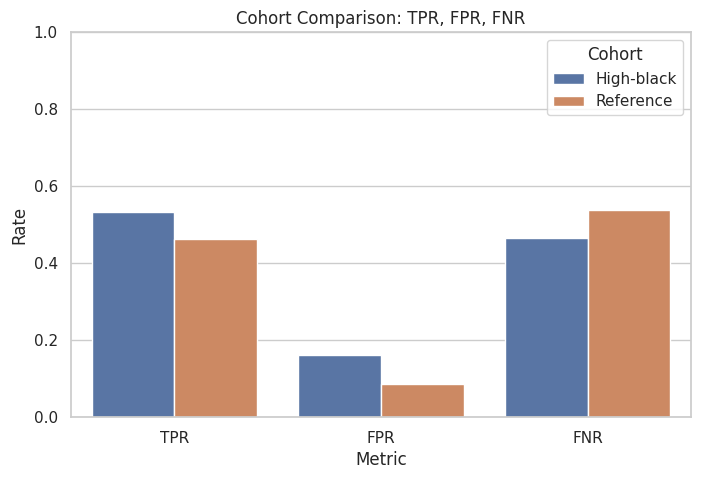

In [11]:
# Step 7: grouped bar chart for TPR, FPR, FNR by cohort.
plot_df = pd.DataFrame({
    "Cohort": ["High-black", "Reference"],
    "TPR": [m_high_black["TPR"], m_reference["TPR"]],
    "FPR": [m_high_black["FPR"], m_reference["FPR"]],
    "FNR": [m_high_black["FNR"], m_reference["FNR"]],
})

plot_long = plot_df.melt(id_vars="Cohort", var_name="Metric", value_name="Value")

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_long, x="Metric", y="Value", hue="Cohort")
plt.title("Cohort Comparison: TPR, FPR, FNR")
plt.ylim(0, 1)
plt.ylabel("Rate")
plt.show()

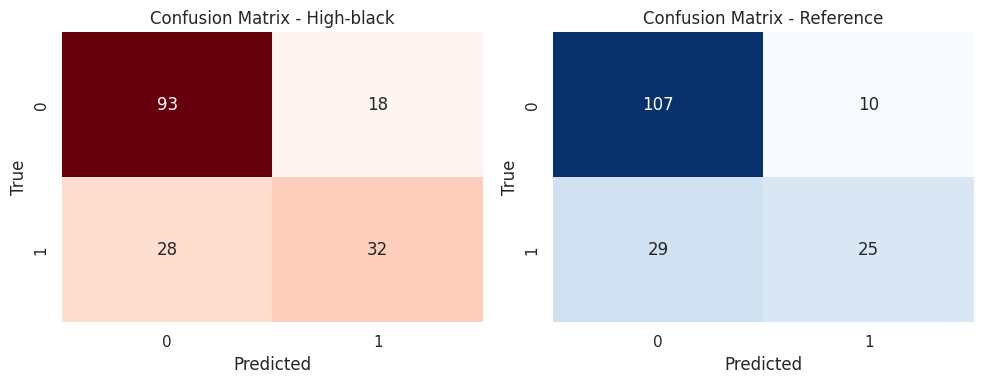

In [ ]:

# Step 8: confusion matrix for each cohort.
cm_high_black = np.array([[m_high_black["TN"], m_high_black["FP"]], [m_high_black["FN"], m_high_black["TP"]]])
cm_reference = np.array([[m_reference["TN"], m_reference["FP"]], [m_reference["FN"], m_reference["TP"]]])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm_high_black, annot=True, fmt="d", cmap="Reds", cbar=False, ax=axes[0])
axes[0].set_title("Confusion Matrix - High-black")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_reference, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("Confusion Matrix - Reference")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

In [13]:
# Step 9: compact final audit table for reporting.
audit_summary = pd.DataFrame([
    {
        "Cohort": "High-black",
        "Size": m_high_black["n"],
        "TPR": m_high_black["TPR"],
        "FPR": m_high_black["FPR"],
        "FNR": m_high_black["FNR"],
        "Precision": m_high_black["Precision"],
    },
    {
        "Cohort": "Reference",
        "Size": m_reference["n"],
        "TPR": m_reference["TPR"],
        "FPR": m_reference["FPR"],
        "FNR": m_reference["FNR"],
        "Precision": m_reference["Precision"],
    },
])

fairness_row = pd.DataFrame([
    {
        "Cohort": "Fairness deltas",
        "Size": np.nan,
        "TPR": np.nan,
        "FPR": disparate_impact_fpr,
        "FNR": eod,
        "Precision": spd,
    }
])

print("Final summary table")
print("Columns in fairness row: FPR=DisparateImpact(FPR ratio), FNR=EqualOpportunityDiff, Precision=StatisticalParityDiff")
display(pd.concat([audit_summary, fairness_row], ignore_index=True))

Final summary table
Columns in fairness row: FPR=DisparateImpact(FPR ratio), FNR=EqualOpportunityDiff, Precision=StatisticalParityDiff


,Cohort,Size,TPR,FPR,FNR,Precision
0,High-black,171.0,0.533333,0.162162,0.466667,0.640000
1,Reference,171.0,0.462963,0.085470,0.537037,0.714286
2,Fairness deltas,NaN,NaN,1.897297,0.070370,0.087719


## Key Question Response (Fill After Running)

Use the computed summary table and plots to answer:
1. Which metric has the largest disparity between high-black and reference cohorts?
2. Is the model predominantly over-flagging (higher FPR), under-flagging (higher FNR), or both for the high-black cohort?
3. What are the real-world consequences of each error direction?

Suggested framing for your write-up:
- If FPR is substantially higher for high-black, innocent comments tied to Black identity are disproportionately removed or sent to review, harming user voice and trust.
- If FNR is higher for high-black, harmful content in that cohort may be missed, reducing protection quality.
- If both are elevated, the system is both less fair and less reliable, requiring mitigation before production use at this threshold.